In [1]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from logging import setLogRecordFactory
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
import time

In [3]:
class Parser:
    def __init__(self):
        self.headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    def parsing(self, ssulka):
        straniza=requests.get(ssulka, headers=self.headers)
        straniza_2=BeautifulSoup(straniza.text, "html.parser")
        return straniza_2
parser_1=Parser()

In [4]:

sait_1=parser_1.parsing("https://proffbar.ru/catalog/mebel-dlya-kofeen?ysclid=mp85kl15qs183762051")
spisok_1=sait_1.find_all("div", class_="products__item item_ajax")
charakters=[]
for i in spisok_1:
    name=i.find("span", class_="products__item-info-name").get_text(strip=True)
    price=i.find("div", class_="products__price-new").get_text(strip=True)
    charakters.append((name,price))

In [5]:
tablica=pd.DataFrame(charakters)
tablica.columns=["Название", "Цена"]
tablica["Цена"]=tablica["Цена"].str.split(" ₽").str[0]
tablica["Цена"]=tablica["Цена"].str.replace(" ", "")
tablica["Цена"]=tablica["Цена"].astype(int)
print(tablica)

                                             Название   Цена
0   Пластиковый стул Ленни-220 белый на деревянных...   2600
1                                           Стул Рафо   7800
2   Деревянное кресло Осмо с подлокотниками цвет с...  15000
3            Кресло Берни натуральный обивка Китон-04  16700
4                Стул Ла Мели с подлокотниками черный   7400
..                                                ...    ...
61          Пластиковый стул Masters (Мастерс) черный   4920
62                    Стул Толикс (Tolix) серебристый   5090
63                   Венский стул Роза цвет венге 325   6300
64                           Венский стул B-165 венге  12800
65                           Венский стул А-165 венге  13700

[66 rows x 2 columns]


In [6]:
driver=webdriver.Chrome()
driver.get("https://pp-cafe.ru/menu")
time.sleep(2)
bluda=driver.find_elements(By.CSS_SELECTOR,".t-store__card")
charakters_2=[]
for i in bluda:
    name=i.find_element(By.CSS_SELECTOR,".t-store__card__title")
    name_new=name.text.strip()
    price=i.find_element(By.CSS_SELECTOR,".t-store__card__price-value")

    price_new=price.text.strip()
    charakters_2.append((name_new,price_new))
driver.quit()
tablica_2=pd.DataFrame(charakters_2)
print(tablica_2)

                                                    0      1
0                             ПП Брауни птичье молоко    300
1   ПП Белковый рулет с вишневым или клубничным дж...  2 800
2                ТОРТ ПП ЧИЗКЕЙК без сахара и глютена  2 800
3                  Клубничный мохито в веган-шоколаде    320
4   КАПКЕЙКИ "Медовик" без сахара и глютена (6, 12...  2 200
5                 Банановый наполеон в веган-шоколаде    300
6                Наполеон «Клубничный Мохито» (Vegan)    315
7                    ТОРТ «Клубничный Мохито» (Vegan)    450
8                Наполеон «Яблочный штрудель» (Vegan)    290
9                        Наполеон «Банановый» (Vegan)    290
10                  ТОРТ Наполеон «Банановый» (Vegan)    400
11               ТОРТ Наполеон «Груша-ваниль» (Vegan)    420
12                    Наполеон «Груша-ваниль» (Vegan)    305
13                  Наполеон «Манго-Маракуйя» (Vegan)    320
14                      ТОРТ «Манго-Маракуйя» (Vegan)    450
15                      

In [7]:
tablica_2.columns=["Название", "Цена"]
tablica_2["Цена"]=tablica_2["Цена"].str.replace(" ", "")
tablica_2["Цена"]=tablica_2["Цена"].astype(int)
print(tablica_2)

                                             Название  Цена
0                             ПП Брауни птичье молоко   300
1   ПП Белковый рулет с вишневым или клубничным дж...  2800
2                ТОРТ ПП ЧИЗКЕЙК без сахара и глютена  2800
3                  Клубничный мохито в веган-шоколаде   320
4   КАПКЕЙКИ "Медовик" без сахара и глютена (6, 12...  2200
5                 Банановый наполеон в веган-шоколаде   300
6                Наполеон «Клубничный Мохито» (Vegan)   315
7                    ТОРТ «Клубничный Мохито» (Vegan)   450
8                Наполеон «Яблочный штрудель» (Vegan)   290
9                        Наполеон «Банановый» (Vegan)   290
10                  ТОРТ Наполеон «Банановый» (Vegan)   400
11               ТОРТ Наполеон «Груша-ваниль» (Vegan)   420
12                    Наполеон «Груша-ваниль» (Vegan)   305
13                  Наполеон «Манго-Маракуйя» (Vegan)   320
14                      ТОРТ «Манго-Маракуйя» (Vegan)   450
15                            ТОРТ "Тира

In [8]:
site_3=parser_1.parsing("https://franko.su/catalog/professionalnye-kofemashiny/?utm_source=yandex&utm_medium=cpc&utm_campaign=704248443&utm_content=17363345305&utm_term=---autotargeting&type1&---autotargeting&1&premium&search&Москва&213&etext=2202.EpgspwgNi3g1ZEIfjrBtZnWgx2g4tSql8eYnxNoop33arZREChC90ZVrixzqKmaeT59TwT5s6hoPirOpQYNYqG5vend2YW9ya3BvaWhrcHo.398941d787353bab559af2a58a420ca73c00f1e0&yclid=9405815566794751999")

In [12]:
driver=webdriver.Chrome()
driver.get("https://franko.su/catalog/professionalnye-kofemashiny/?utm_source=yandex&utm_medium=cpc&utm_campaign=704248443&utm_content=17363345305&utm_term=---autotargeting&type1&---autotargeting&1&premium&search&Москва&213&etext=2202.EpgspwgNi3g1ZEIfjrBtZnWgx2g4tSql8eYnxNoop33arZREChC90ZVrixzqKmaeT59TwT5s6hoPirOpQYNYqG5vend2YW9ya3BvaWhrcHo.398941d787353bab559af2a58a420ca73c00f1e0&yclid=9405815566794751999")
time.sleep(5)
spisok_3=driver.find_elements(By.CSS_SELECTOR,".catalog_item_wrapp")
charakters_3=[]
for i in spisok_3:
    fig=i.find_element(By.CSS_SELECTOR, ".item-title")
    name=fig.text.strip()
    price=i.find_element(By.CSS_SELECTOR, ".price_value").text.strip()
    charakters_3.append((name, price))
driver.execute_script("window.scrollTo(0, window.innerHeight * 5);")
time.sleep(5)

spisok_4=driver.find_elements(By.CSS_SELECTOR,".catalog_item_wrapp")

for i in spisok_4:
    fig=i.find_element(By.CSS_SELECTOR, ".item-title")
    name=fig.text.strip()
    price=i.find_element(By.CSS_SELECTOR, ".price_value").text.strip()
    charakters_3.append((name, price))

driver.execute_script("window.scrollTo(0, window.innerHeight * 10);")
time.sleep(5)

spisok_5=driver.find_elements(By.CSS_SELECTOR,".catalog_item_wrapp")

for i in spisok_5:
    fig=i.find_element(By.CSS_SELECTOR, ".item-title")
    name=fig.text.strip()
    price=i.find_element(By.CSS_SELECTOR, ".price_value").text.strip()
    charakters_3.append((name, price))


driver.execute_script("window.scrollTo(0, window.innerHeight * 15);")
time.sleep(5)

spisok_6=driver.find_elements(By.CSS_SELECTOR,".catalog_item_wrapp")

for i in spisok_6:
    fig=i.find_element(By.CSS_SELECTOR, ".item-title")
    name=fig.text.strip()
    price=i.find_element(By.CSS_SELECTOR, ".price_value").text.strip()
    charakters_3.append((name, price))



driver.quit()

tablica_3=pd.DataFrame(charakters_3)
tablica_3 = tablica_3.drop_duplicates()
tablica_3.reset_index(drop=True, inplace=True)

tablica_3.columns=["Название", "Цена"]
tablica_3["Цена"]=tablica_3["Цена"].str.replace(" ", "")
tablica_3["Цена"]=tablica_3["Цена"].astype(int)
print(tablica_3)



                                             Название     Цена
0     Эспрессо-кофемашина Dalla Corte ICON (3 группы)  1467294
1   Профессиональная капельная фильтр-кофемашина M...   451662
2     Эспрессо-кофемашина DALLA CORTE EVO2 (3 группы)  1389062
3   Эспрессо-кофемашина Dalla Corte XT Classic (3 ...  1745454
4   Эспрессо-кофемашина Dalla Corte ZERO PLUS (2 г...  2190510
5   Эспрессо-кофемашина Dalla Corte ZERO PLUS Clas...  1773270
6     Эспрессо-кофемашина DALLA CORTE EVO2 (4 группы)  1586092
7   Эспрессо-кофемашина Dalla Corte ZERO PLUS (3 г...  2700470
8   Эспрессо-кофемашина Dalla Corte ZERO PLUS Clas...  2167330
9   Эспрессо-кофемашина DALLA CORTE EVO2 HV (2 гру...  1296342
10  Эспрессо-кофемашина Dalla Corte STUDIO (1 груп...   492575
11  Эспрессо-кофемашина DALLA CORTE EVO2 HV (3 гру...  1518870
12  Профессиональная система приготовления фильтр-...   377718
13  Эспрессо-кофемашина Dalla Corte XT Classic (2 ...  1490474
14  Капельная кофеварка FLT 120 AP Термос с пневмо...  

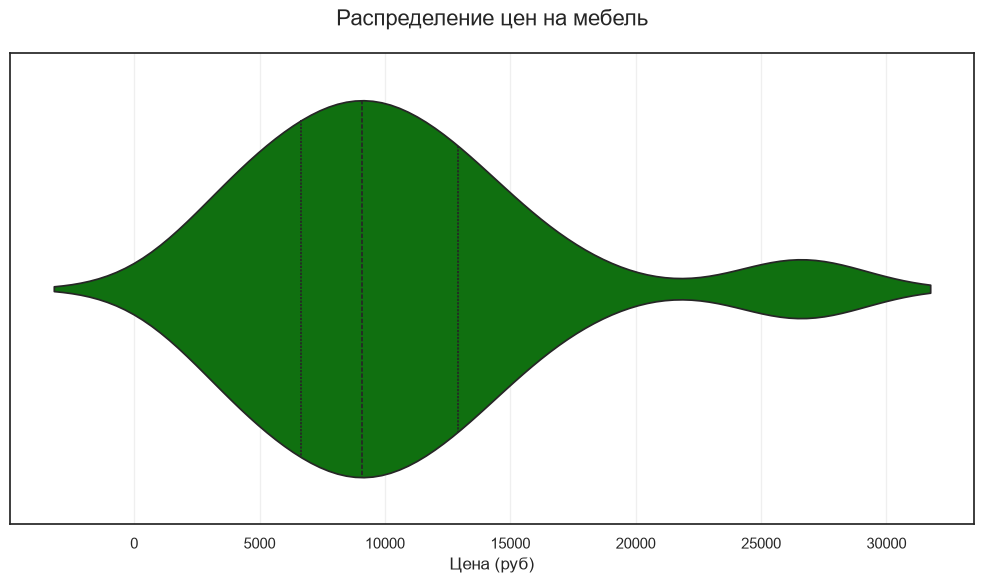

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcdefaults()
sns.set_style("whitegrid")
sns.set_palette("husl")

sns.set_theme(style="white", rc={"axes.facecolor": "white", "figure.facecolor": "white"})

plt.figure(figsize=(10, 6))

sns.violinplot(data=tablica, x='Цена', color='green', inner='quartile')

plt.title('Распределение цен на мебель', fontsize=16, pad=20)
plt.xlabel('Цена (руб)', fontsize=12)
plt.grid(axis='x', alpha=0.3)

plt.gca().set_facecolor('white')
plt.gcf().patch.set_facecolor('white')

plt.tight_layout()
plt.show()

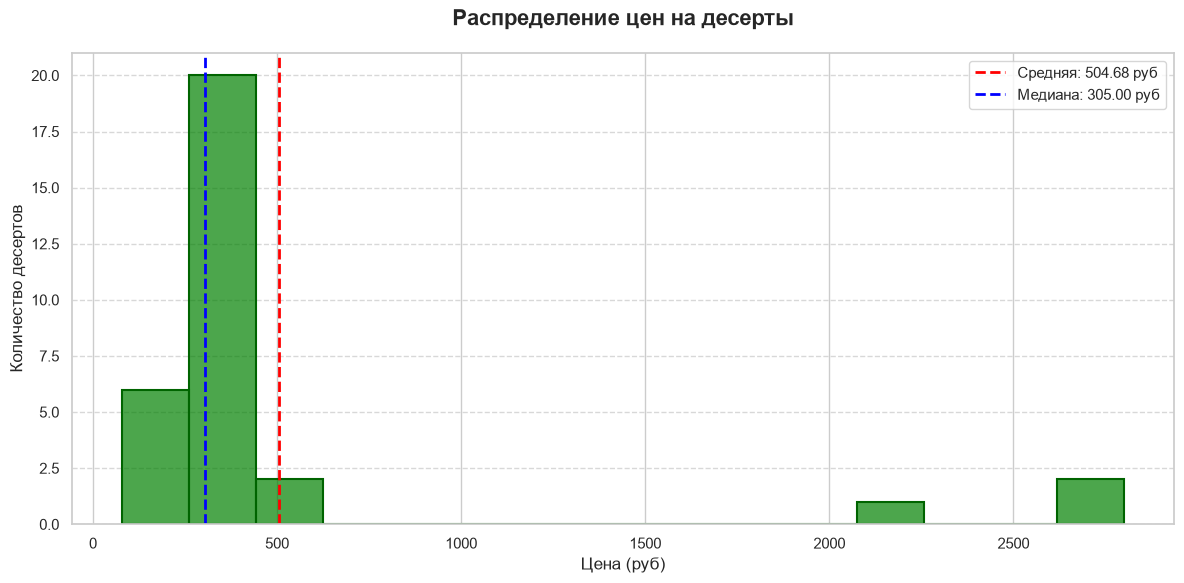

In [28]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
sns.histplot(data=tablica_2, x='Цена', bins=15, color='green',
             alpha=0.7, edgecolor='darkgreen', linewidth=1.5, ax=ax)

ax.set_title('Распределение цен на десерты', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Цена (руб)', fontsize=12)
ax.set_ylabel('Количество десертов', fontsize=12)
ax.grid(axis='y', alpha=0.3, color='gray', linestyle='--')

mean_price = tablica_2['Цена'].mean()
median_price = tablica_2['Цена'].median()
ax.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Средняя: {mean_price:.2f} руб')
ax.axvline(median_price, color='blue', linestyle='--', linewidth=2, label=f'Медиана: {median_price:.2f} руб')
ax.legend()



plt.tight_layout()
plt.show()

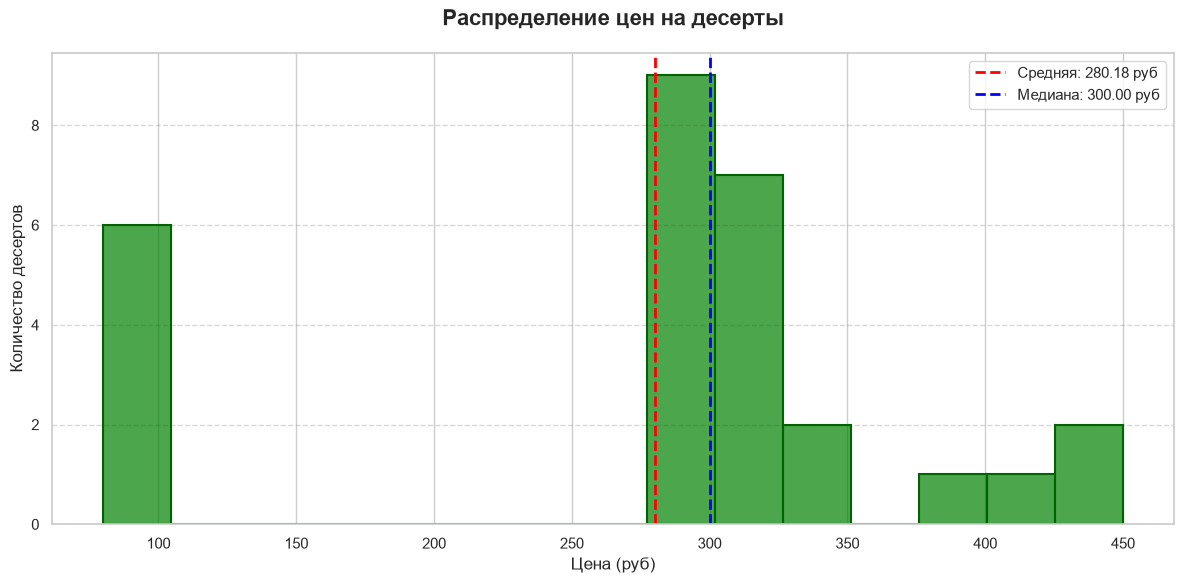

In [29]:
tablica_2_filtered=tablica_2[tablica_2["Цена"]<=800]
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
sns.histplot(data=tablica_2_filtered, x='Цена', bins=15, color='green',
             alpha=0.7, edgecolor='darkgreen', linewidth=1.5, ax=ax)

ax.set_title('Распределение цен на десерты', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Цена (руб)', fontsize=12)
ax.set_ylabel('Количество десертов', fontsize=12)
ax.grid(axis='y', alpha=0.3, color='gray', linestyle='--')

mean_price = tablica_2_filtered['Цена'].mean()
median_price = tablica_2_filtered['Цена'].median()
ax.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Средняя: {mean_price:.2f} руб')
ax.axvline(median_price, color='blue', linestyle='--', linewidth=2, label=f'Медиана: {median_price:.2f} руб')
ax.legend()



plt.tight_layout()
plt.show()

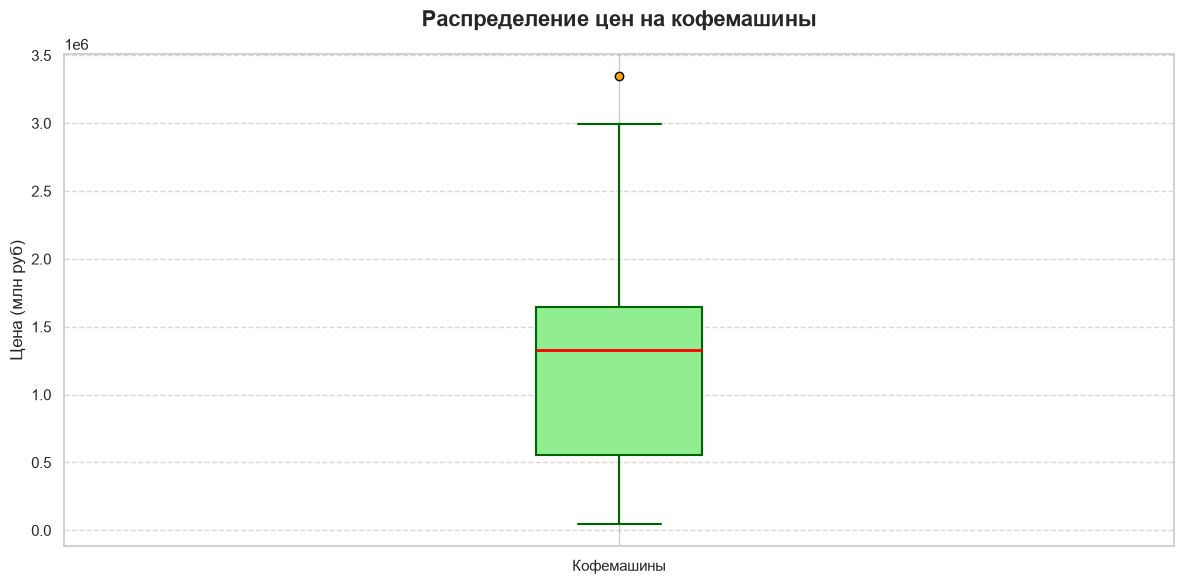

In [31]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

bp = ax.boxplot(tablica_3['Цена'], patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen', linewidth=1.5),
                whiskerprops=dict(color='darkgreen', linewidth=1.5),
                capprops=dict(color='darkgreen', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='orange', markersize=6, linestyle='none'))

ax.set_title('Распределение цен на кофемашины', fontsize=16, pad=20, fontweight='bold')
ax.set_ylabel('Цена (млн руб)', fontsize=12)
ax.set_xticklabels(['Кофемашины'])
ax.grid(axis='y', alpha=0.3, color='gray', linestyle='--')

plt.tight_layout()
plt.show()